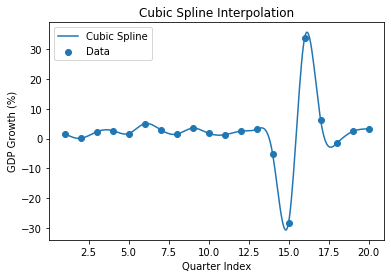

In [7]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(1, 21)
y = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8,
              1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3])

import numpy as np

def spline_coeffs(x, y):
    n = len(x)
    h = np.diff(x)
    A = np.zeros((n-2, n-2))
    rhs = np.zeros(n-2)

    for i in range(n-2):
        if i > 0:
            A[i, i-1] = h[i]
        A[i, i] = 2 * (h[i] + h[i+1])
        if i < n-3:
            A[i, i+1] = h[i+1]
        rhs[i] = 3 * ((y[i+2] - y[i+1]) / h[i+1] - (y[i+1] - y[i]) / h[i])

    c = np.zeros(n)
    c[1:-1] = np.linalg.solve(A, rhs)

    b = np.zeros(n-1)
    d = np.zeros(n-1)

    for i in range(n-1):
        b[i] = (y[i+1] - y[i]) / h[i] - h[i] * (2*c[i] + c[i+1]) / 3
        d[i] = (c[i+1] - c[i]) / (3*h[i])

    return y, b, c, d

def eval_spline(x_data, coeffs, x_val):
    y, b, c, d = coeffs
    for i in range(len(x_data)-1):
        if x_data[i] <= x_val <= x_data[i+1]:
            dx = x_val - x_data[i]
            return y[i] + b[i]*dx + c[i]*dx**2 + d[i]*dx**3
        
import matplotlib.pyplot as plt
import numpy as np

coeffs = spline_coeffs(x, y)
x_dense = np.linspace(min(x), max(x), 300)
spline_y = [eval_spline(x, coeffs, val) for val in x_dense]

plt.scatter(x, y, label="Data")
plt.plot(x_dense, spline_y, label="Cubic Spline")
plt.xlabel("Quarter Index")
plt.ylabel("GDP Growth (%)")
plt.title("Cubic Spline Interpolation")
plt.legend()
plt.show()

Part A - Cubic Spline Interpolation

For a dataset of n points, the cubic spline is made up of n-1 cubic polynomials
(S_i(x) = a_i + b_i(x- x_i) + c_i(x- x_i)^2 + d_i(x- x_i)^3)

In this scenario, the number of unknowns is given by 4(n-1)

Necessary Conditions: Interpolation at endpoints of each given interval - Continuity of the first derivative - Continuity of the second derivative - Natural boundary conditions: S’‘(x1) = 0 and S”(xn) = 0

Therefore, is reduced to a tridiagonal system of size (n-2) x (n-2)

A tridiagonal system occurs when only neighboring spline segments are involved

This spline is continuous throughout all intervals and passes through each of the various data points. The spline was evaluated through all 55 quarters. The spline is able to demonstrate the overall trend. The Spline is smooth due to the first and second derivative being continuous. However, at the extreme values during Covid, the graph shows a large amount of curvature that differs greatly from any other points in the spline. This example is localized. This instance shows that although splines avoid Runge Phenomenon, they are still susceptible to interpolating extreme outliers in a data set. For clarification, the Runge Phenomenon is when oscillations in high degree polynomials that splines avoid through the use of low-degree polynomials. When addressing datasets with significant outliers, it is better to use a method such as weighted least squares due to its lower sensitivity to extreme values. Ultimately, the Spline is reasonable except for at the local extremes mentioned.

Part B - Polynomial and Least Squares Comparison

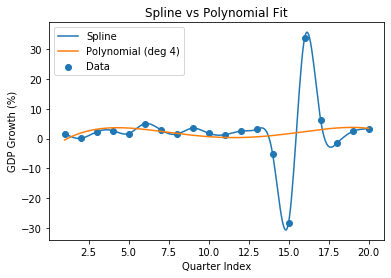

In [8]:
def poly_fit(x, y, deg):
    A = np.vander(x, deg + 1, increasing=True)
    ATA = A.T @ A
    ATy = A.T @ y
    return np.linalg.solve(ATA, ATy)

poly_c = poly_fit(x, y, 4)

x_dense = np.linspace(min(x), max(x), 300)
poly_y = np.polyval(poly_c[::-1], x_dense)

plt.scatter(x, y, label="Data")
plt.plot(x_dense, spline_y, label="Spline")
plt.plot(x_dense, poly_y, label="Polynomial (deg 4)")

plt.xlabel("Quarter Index")
plt.ylabel("GDP Growth (%)")
plt.title("Spline vs Polynomial Fit")

plt.legend()
plt.show()

It should be noted that the polynomial demonstrates the overall trend but does not go through every data point. Alternatively, a Spline passes through all of the given data points. The benefit of the Spline is that gives it an "exact-fit" and is better for specific points, while the benefit of the polynomial method is that it gives an overall smoother trend. In other words, the Spline method is better for mapping specific points while the polynomial method is better for generalization. In this example the polynomial degree is 4. The polynomial is obtained using a least squares fit method. When the two methods are plotted side by side it becomes evident that the spline method goes through each point exactly while the alternative polynomial method is more general in respect to the overall dataset.

Slope: -0.017336448598130803


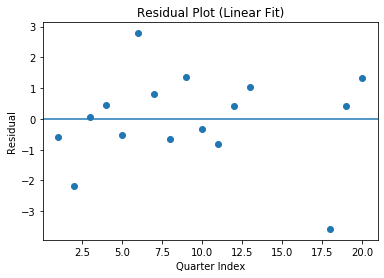

In [9]:
import numpy as np
import matplotlib.pyplot as plt

mask = (x < 14) | (x > 17)
x_clean = x[mask]
y_clean = y[mask]

A = np.vstack([x_clean, np.ones(len(x_clean))]).T
ATA = A.T @ A
ATy = A.T @ y_clean

m, b = np.linalg.solve(ATA, ATy)
print("Slope:", m)

y_pred = m * x_clean + b
residuals = y_clean - y_pred

plt.scatter(x_clean, residuals)
plt.axhline(0)
plt.xlabel("Quarter Index")
plt.ylabel("Residual")
plt.title("Residual Plot (Linear Fit)")
plt.show()

The slope is about - 0.017 which demonstrates small economic decay over time when excluding the Covid period. In regards to linear models, they assume constant growth while ignoring prominent disruptions. Despite this shortcoming, linear fits are useful in illustrating short term trends. Basically, linear modules are best utilized over short periods. The model is able approximate data but does not illustrate all fluctuations since residuals vary around 0. This means that it does not accurately capture all variability.

Part C - Method Justification 

The Cubic Spline Method is ideal for estimating the GDP value between points/quarters because they are both precise and smooth. This is due to the fact that Splines allow for smooth curves and correct interpolation while keeping local behavior preserved. Furthermore, outliers only affect a spline locally and not along the entire curve. Alternatively, Polynomial fitting is far more sensitive to dramatic outliers which can create dramatic oscillations through the entire curve. Polynomial fitting is less precise at individual points. Ultimately, Cubic Splines are far more reliable for analysts that need more precise interpolation due to them looking at quarters more individually. 

Conclusion

Overall, Cubic Splines, despite being sensitive to extreme point (such as the ones during Covid), are best for interpolation since they create smooth curves that travel through each data point. Polynomial fitting is able to show the general trend but is not nearly as precise locally as the aforementioned method. Linear Regression offers a decent trend, but it depends on assumptions that may not hold up throughout the entirety of a data set. This project was effective in demonstrating the advantages of using different numerical methods in different scenarios. It showed that some methods are better in certain scenarios versus others depending on what the goal is.